# Predict Future Stock Prices (Short-Term)

In [1]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# Import libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


## Step 1: Load Stock Data

In [3]:
# Download Apple stock data
data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

[*********************100%***********************]  1 of 1 completed


In [4]:
# Display first 5 rows
print("First 5 Rows:")
print(data.head())

First 5 Rows:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333878  72.394086  71.091184  71.344054  135480400
2020-01-03  71.630646  72.389265  71.406674  71.563213  146322800
2020-01-06  72.201424  72.239958  70.503561  70.754028  118387200
2020-01-07  71.861855  72.466338  71.642697  72.211056  108872000
2020-01-08  73.017853  73.318893  71.565636  71.565636  132079200


## Step 2: Select Features & Target

In [5]:
# Features
X = data[['Open', 'High', 'Low', 'Volume']]

In [6]:
# Target
y = data['Close']

## Step 3: Split Dataset

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 4: Train Linear Regression Model

In [8]:
model = LinearRegression()

In [9]:

# Train model
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Step 5: Predict Prices

In [10]:
y_pred = model.predict(X_test)

## Step 6: Evaluate Model

In [11]:
mse = mean_squared_error(y_test, y_pred)

print("\nMean Squared Error:")
print(mse)


Mean Squared Error:
0.8997851330379761


## Step 7: Plot Actual vs Predicted Prices

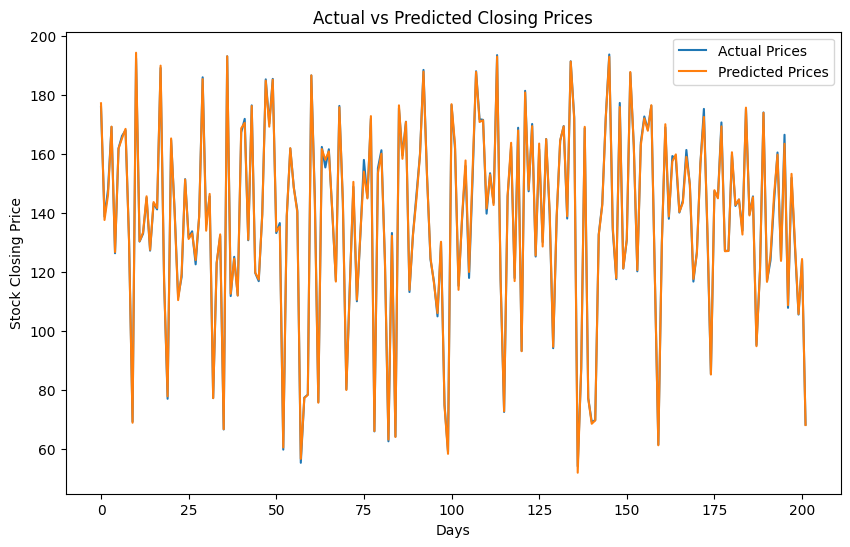

In [12]:
plt.figure(figsize=(10,6))

plt.plot(y_test.values, label='Actual Prices')
plt.plot(y_pred, label='Predicted Prices')

plt.title('Actual vs Predicted Closing Prices')
plt.xlabel('Days')
plt.ylabel('Stock Closing Price')
plt.legend()

plt.show()